# Topic 5 Neural Networks

In [58]:
import numpy as np
from PIL import Image
import os

In [39]:
# Activation function (Sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

### Step 1.
Programar una capa de entrada, una capa oculta con una neurona y una capa de salida.

In [ ]:
# Load the data
input = np.random.random(10)       # Input data

# Initialize the NN parameters
weights = np.random.random(10)     # Weights
bias = np.random.random()          # Bias

In [75]:
# Output of the neuron
output = sigmoid(np.dot(input, weights) + bias)
print("Initial output:", output)

# Gradient descent (simplified)
learning_rate = 0.01
target = 0.5  # Target output
error = output - target
weights -= learning_rate * error * input
bias -= learning_rate * error

output = sigmoid(np.dot(input, weights) + bias)
print("Output after training:", output)

Initial output: 0.9520386762090629
Output after training: 0.9510039545598606


### Step 2
Probar la efectiviada de la NN con imágenes sencillas

In [94]:
# Load the images
img_path = 'dataset/1/fighter'  # Base path to the dataset

classes = {'f35': 0, 'su57': 1}  # Classes in the dataset
images = []  # List to store image data
labels = []  # List to store corresponding labels

for class_idx in classes:
    for img_file in os.listdir(os.path.join(img_path, class_idx)):
        if img_file.lower().endswith(('.jpeg', '.jpg', 'png')):
            img_file = os.path.join(img_path, class_idx, img_file)  # Full path to the image
            img = Image.open(img_file)  # Load an image
            img = img.convert('RGB')  # Ensure it's in RGB format
            img = img.resize((224, 224))  # Resize the image to a fixed size
            img_array = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
            images.append(img_array)  # Store the image array
            labels.append(classes.get(class_idx))  # Store the corresponding label

print(np.array(images).shape)  # Should print (num_images, 224, 224, 3)
print(np.array(labels).shape)  # Should print (num_images,)

(546, 224, 224, 3)
(546,)


In [ ]:
# Set the training and test batches randomly
shuffled_indices = np.random.permutation(len(images)) # Shuffle the indices of the dataset
images = np.array(images)[shuffled_indices]
labels = np.array(labels)[shuffled_indices]
train_images = np.array(images[:int(0.8 * len(images))])
train_labels = np.array(labels[:int(0.8 * len(labels))])
test_images = np.array(images[int(0.8 * len(images)):])
test_labels = np.array(labels[int(0.8 * len(labels)):])

In [96]:
# Use of the NN on one image (simplified)
def simple_nn(image):
    # Flatten the image
    input_vector = image.flatten()
    
    # Initialize random weights and bias for demonstration
    weights = np.random.random(input_vector.shape[0])
    bias = np.random.random()

    # Gradient descent (simplified)
    learning_rate = 0.01
    target = test_labels[0]  # Target output for demonstration
    output = sigmoid(np.dot(input_vector, weights) + bias)
    error = output - target
    weights -= learning_rate * error * input_vector
    bias -= learning_rate * error
    
    # Compute the output
    output = sigmoid(np.dot(input_vector, weights) + bias)
    return output

# Test the NN on a sample image
sample_image = test_images[0]  # Take the first image from the test set
nn_output = simple_nn(sample_image)
print("NN output for the sample image:", nn_output)
print("True label for the sample image:", test_labels[0])

NN output for the sample image: 1.0
True label for the sample image: 1


In [124]:
# Training the NN on the training set (simplified)
def train_nn(train_images, train_labels):
    # Initialize random weights and bias for demonstration
    input_size = train_images[0].flatten().shape[0]
    weights = np.random.random(input_size)
    bias = np.random.random()

    loss_history = []  # To store loss values for each epoch

    # Gradient descent (simplified)
    learning_rate = 0.01
    for epoch in range(50):  # Number of epochs
        for img, label in zip(train_images, train_labels):
            input_vector = img.flatten()
            output = sigmoid(np.dot(input_vector, weights) + bias)
            error = output - label
            weights -= learning_rate * error * input_vector
            bias -= learning_rate * error

            # Extract the loss function (simplified)
            loss = -(1/len(train_images)) * np.sum(label * np.log(output) + (1 - label) * np.log(1 - output))
            loss_history.append(loss)

    return weights, bias, loss_history

# Train the NN
weights, bias, loss_history = train_nn(train_images, train_labels)

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/2692749187.py:21: RuntimeWarning: divide by zero encountered in log
  loss = -(1/len(train_images)) * np.sum(label * np.log(output) + (1 - label) * np.log(1 - output))
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/2692749187.py:21: RuntimeWarning: invalid value encountered in scalar multiply
  loss = -(1/len(train_images)) * np.sum(label * np.log(output) + (1 - label) * np.log(1 - output))
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [125]:
# Test the NN on the test set
def test_nn(test_images, test_labels, weights, bias):
    correct_predictions = 0
    for img, label in zip(test_images, test_labels):
        input_vector = img.flatten()
        output = sigmoid(np.dot(input_vector, weights) + bias)
        predicted_label = 1 if output >= 0.5 else 0  # Thresholding at 0.5
        if predicted_label == label:
            correct_predictions += 1
    accuracy = correct_predictions / len(test_labels)
    return accuracy

accuracy = test_nn(test_images, test_labels, weights, bias)
print("Test accuracy:", accuracy)

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Test accuracy: 0.5909090909090909


In [126]:
# Test for overfitting (simplified)
def check_overfitting(train_images, train_labels, test_images, test_labels, weights, bias):
    train_accuracy = test_nn(train_images, train_labels, weights, bias)
    test_accuracy = test_nn(test_images, test_labels, weights, bias)
    print("Train accuracy:", train_accuracy)
    print("Test accuracy:", test_accuracy)
    if train_accuracy > 0.9 and test_accuracy < 0.7:
        print("The model is likely overfitting.")
    else:
        print("The model is not overfitting.")

check_overfitting(train_images, train_labels, test_images, test_labels, weights, bias)

/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_22265/3763185503.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Train accuracy: 0.6857798165137615
Test accuracy: 0.5909090909090909
The model is not overfitting.


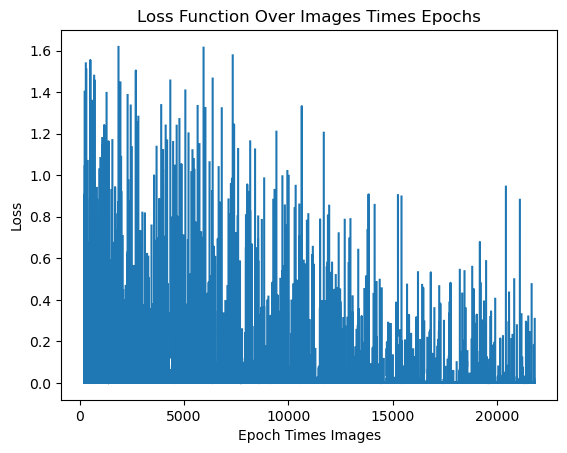

In [ ]:
# Plotting the loss function (simplified)
import matplotlib.pyplot as plt
def plot_loss(loss_history):
    plt.plot(loss_history)
    plt.title('Loss Function Over Images Times Epochs')
    plt.xlabel('Epoch Times Images')
    plt.ylabel('Loss')
    plt.show()

# Assuming loss_history is collected during training
plot_loss(loss_history) 